In [34]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [35]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'x'}

In [36]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test5/rolling_x
['reference', 'info.json', 'target']


In [37]:
TARGET_VAR = 'pitch'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [120, 150], 'static': [200, 300]}
[200, 300]
[120, 150]


# IMPORTANDO DADOS

In [38]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df

,ay,sample_time,q1,roll,wz,la_pos_mon_d,wy,q3,pitch,q2,wx,az,time,ax,q0,yaw
0,9.784,505000000.0,-0.322300,-1.552,0.000200,-0.3090,-0.002792,0.6560,0.07313,-0.6219,0.000113,-0.1873,4.768372e-07,0.13850,0.28120,2.260
1,9.783,605000000.0,-0.322200,-1.552,0.000064,-0.3074,-0.002719,0.6561,0.07312,-0.6219,-0.000451,-0.1870,5.126691e-02,0.13830,0.28110,2.260
2,9.784,705000000.0,-0.322100,-1.552,0.000052,-0.3058,-0.002813,0.6561,0.07313,-0.6220,-0.000135,-0.1871,1.569357e-01,0.13850,0.28100,2.260
3,9.784,805000000.0,-0.322000,-1.552,0.000069,-0.3041,-0.002721,0.6561,0.07313,-0.6220,-0.000360,-0.1870,2.522373e-01,0.13840,0.28090,2.261
4,9.788,905000000.0,-0.321900,-1.552,-0.002890,-0.3025,-0.003100,0.6562,0.07305,-0.6220,0.001152,-0.2066,3.592129e-01,0.07937,0.28090,2.261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3272,9.786,705000000.0,-0.004071,-1.552,-0.000195,1.3230,-0.002825,0.7134,0.03259,-0.7005,-0.000327,-0.1848,3.271838e+02,0.13890,-0.01911,-3.120
3273,9.785,805000000.0,-0.003973,-1.552,-0.000282,1.3200,-0.002852,0.7134,0.03258,-0.7005,-0.000041,-0.1847,3.272803e+02,0.13880,-0.01921,-3.120
3274,9.784,905000000.0,-0.003864,-1.552,-0.000034,1.3170,-0.002890,0.7134,0.03257,-0.7005,0.000015,-0.1851,3.273756e+02,0.13870,-0.01931,-3.119
3275,9.783,5000000.0,-0.003773,-1.552,-0.000179,1.3140,-0.002616,0.7134,0.03257,-0.7005,-0.000157,-0.1845,3.274734e+02,0.13880,-0.01940,-3.119


- Convertendo pra radianos

In [39]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,ay,sample_time,q1,roll,wz,la_pos_mon_d,wy,q3,pitch,q2,wx,az,time,ax,q0,yaw
0,9.784,505000000.0,-0.322300,-88.92305,0.011459,-0.3090,-0.159970,0.6560,4.190040,-0.6219,0.006486,-0.1873,4.768372e-07,0.13850,0.28120,129.488462
1,9.783,605000000.0,-0.322200,-88.92305,0.003687,-0.3074,-0.155787,0.6561,4.189467,-0.6219,-0.025835,-0.1870,5.126691e-02,0.13830,0.28110,129.488462
2,9.784,705000000.0,-0.322100,-88.92305,0.002988,-0.3058,-0.161173,0.6561,4.190040,-0.6220,-0.007729,-0.1871,1.569357e-01,0.13850,0.28100,129.488462
3,9.784,805000000.0,-0.322000,-88.92305,0.003954,-0.3041,-0.155902,0.6561,4.190040,-0.6220,-0.020626,-0.1870,2.522373e-01,0.13840,0.28090,129.545757
4,9.788,905000000.0,-0.321900,-88.92305,-0.165585,-0.3025,-0.177617,0.6562,4.185457,-0.6220,0.066005,-0.2066,3.592129e-01,0.07937,0.28090,129.545757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3272,9.786,705000000.0,-0.004071,-88.92305,-0.011150,1.3230,-0.161861,0.7134,1.867269,-0.7005,-0.018707,-0.1848,3.271838e+02,0.13890,-0.01911,-178.762832
3273,9.785,805000000.0,-0.003973,-88.92305,-0.016163,1.3200,-0.163408,0.7134,1.866696,-0.7005,-0.002348,-0.1847,3.272803e+02,0.13880,-0.01921,-178.762832
3274,9.784,905000000.0,-0.003864,-88.92305,-0.001921,1.3170,-0.165585,0.7134,1.866124,-0.7005,0.000886,-0.1851,3.273756e+02,0.13870,-0.01931,-178.705536
3275,9.783,5000000.0,-0.003773,-88.92305,-0.010227,1.3140,-0.149886,0.7134,1.866124,-0.7005,-0.008973,-0.1845,3.274734e+02,0.13880,-0.01940,-178.705536


In [40]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,ay,sample_time,q1,roll,wz,la_pos_mon_d,wy,q3,pitch,q2,wx,az,time,ax,q0,yaw


# VISUALIZAÇÃO DE VARIÁVEIS

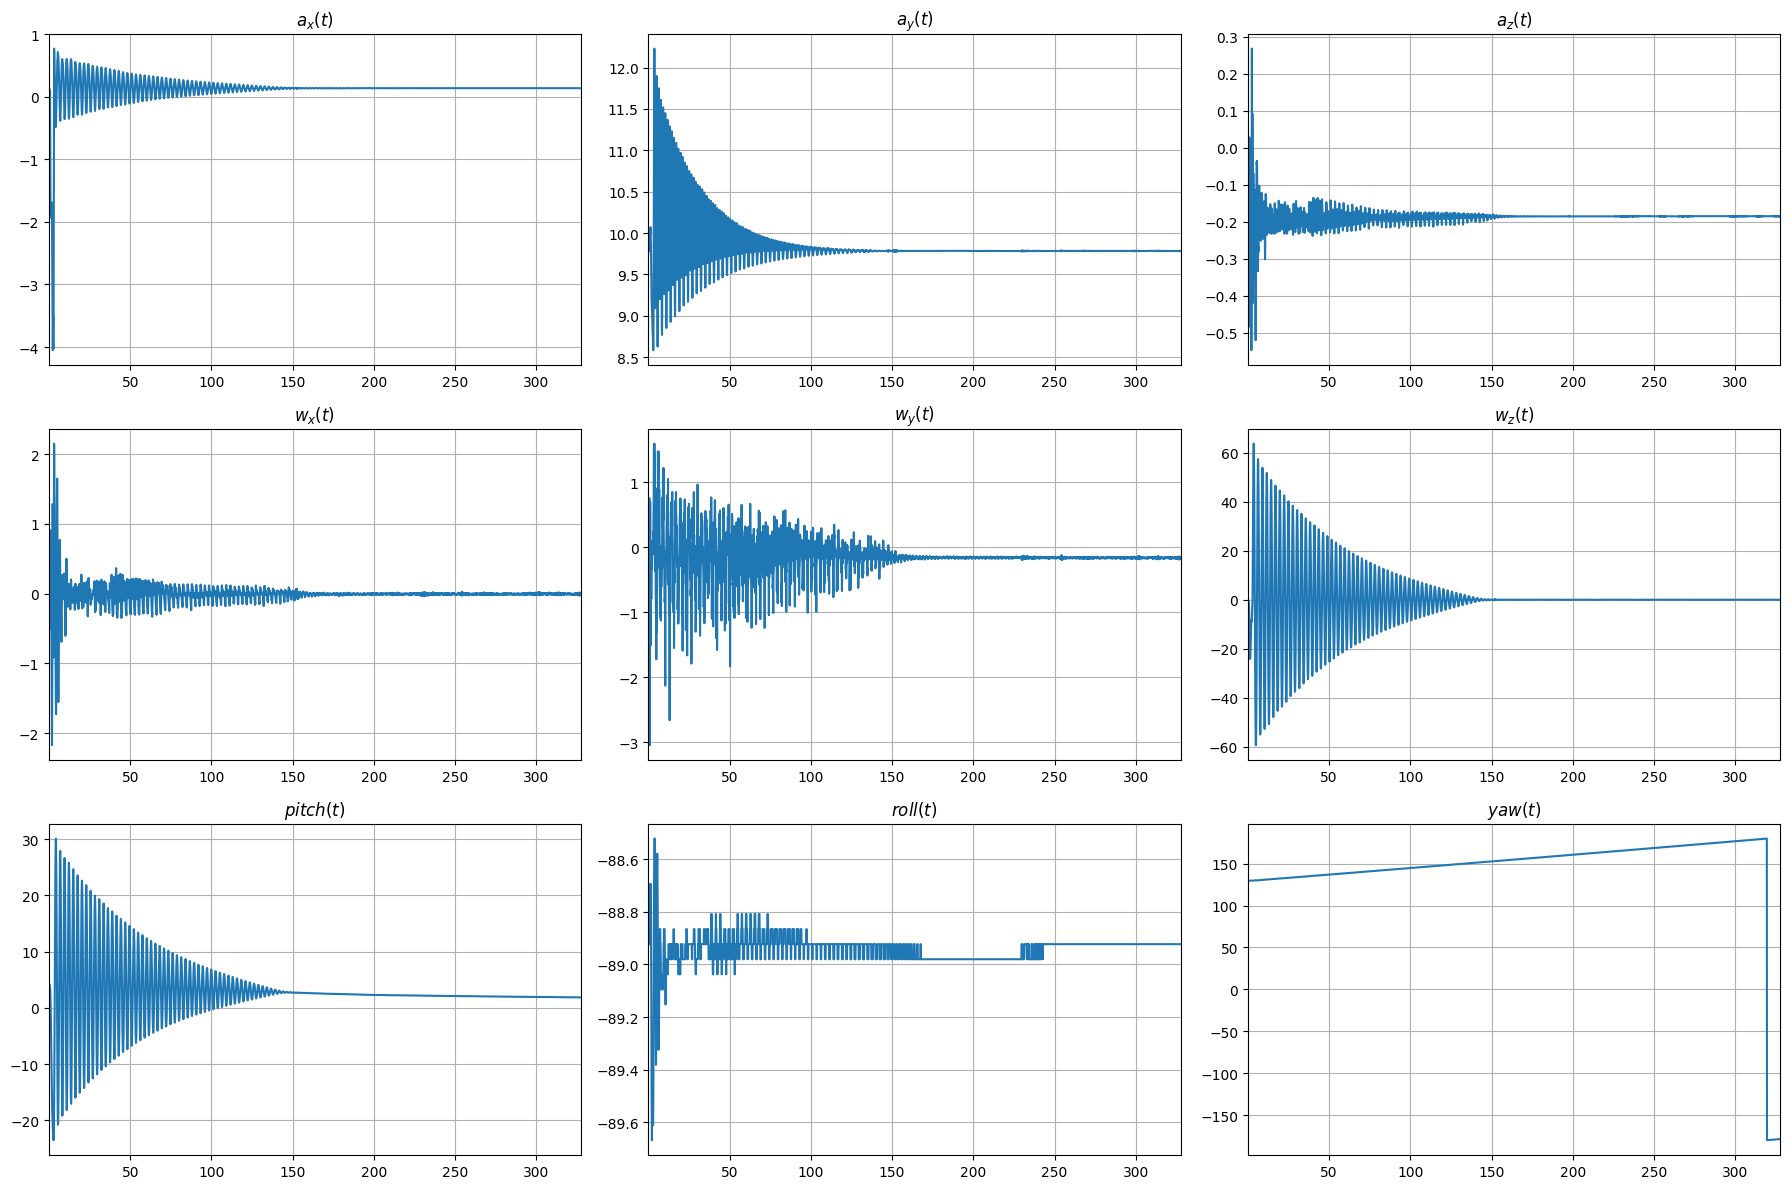

In [41]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

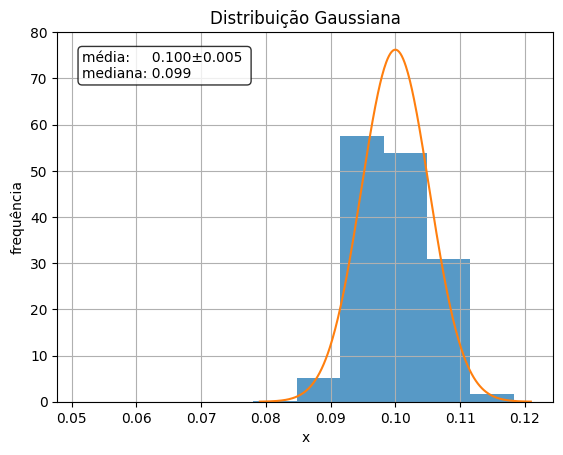

,time,ay,sample_time,q1,roll,wz,la_pos_mon_d,wy,q3,pitch,q2,wx,az,ax,q0,yaw
0,0.0,9.784,505000000.0,-0.322300,-88.92305,0.011459,-0.3090,-0.159970,0.6560,4.190040,-0.6219,0.006486,-0.1873,0.13850,0.28120,129.488462
1,0.1,9.783,605000000.0,-0.322200,-88.92305,0.003687,-0.3074,-0.155787,0.6561,4.189467,-0.6219,-0.025835,-0.1870,0.13830,0.28110,129.488462
2,0.2,9.784,705000000.0,-0.322100,-88.92305,0.002988,-0.3058,-0.161173,0.6561,4.190040,-0.6220,-0.007729,-0.1871,0.13850,0.28100,129.488462
3,0.3,9.784,805000000.0,-0.322000,-88.92305,0.003954,-0.3041,-0.155902,0.6561,4.190040,-0.6220,-0.020626,-0.1870,0.13840,0.28090,129.545757
4,0.4,9.788,905000000.0,-0.321900,-88.92305,-0.165585,-0.3025,-0.177617,0.6562,4.185457,-0.6220,0.066005,-0.2066,0.07937,0.28090,129.545757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3272,327.2,9.786,705000000.0,-0.004071,-88.92305,-0.011150,1.3230,-0.161861,0.7134,1.867269,-0.7005,-0.018707,-0.1848,0.13890,-0.01911,-178.762832
3273,327.3,9.785,805000000.0,-0.003973,-88.92305,-0.016163,1.3200,-0.163408,0.7134,1.866696,-0.7005,-0.002348,-0.1847,0.13880,-0.01921,-178.762832
3274,327.4,9.784,905000000.0,-0.003864,-88.92305,-0.001921,1.3170,-0.165585,0.7134,1.866124,-0.7005,0.000886,-0.1851,0.13870,-0.01931,-178.705536
3275,327.5,9.783,5000000.0,-0.003773,-88.92305,-0.010227,1.3140,-0.149886,0.7134,1.866124,-0.7005,-0.008973,-0.1845,0.13880,-0.01940,-178.705536


In [42]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [43]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,ay,sample_time,q1,roll,wz,la_pos_mon_d,wy,q3,pitch,q2,wx,az,ax,q0,yaw,static
0,0.0,9.770,605000000.0,-0.20360,-88.92305,3.089388,-1.404,-0.055961,0.6888,1.738354,-0.6702,0.042531,-0.1864,0.1592,0.186700,147.994998,False
1,0.1,9.777,705000000.0,-0.20560,-88.92305,3.720788,-1.404,-0.097346,0.6894,2.093015,-0.6696,0.043699,-0.1864,0.1522,0.184500,147.994998,False
2,0.2,9.785,805000000.0,-0.20790,-88.92305,4.145350,-1.404,-0.161345,0.6901,2.496377,-0.6689,0.009305,-0.1857,0.1448,0.182000,147.994998,False
3,0.3,9.791,905000000.0,-0.21030,-88.92305,4.332707,-1.404,-0.140375,0.6908,2.924950,-0.6681,0.008417,-0.1853,0.1363,0.179300,148.052294,False
4,0.4,9.795,5000000.0,-0.21280,-88.92305,4.283432,-1.404,-0.107773,0.6915,3.355814,-0.6673,-0.011471,-0.1852,0.1268,0.176600,148.052294,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.786,105000000.0,-0.03197,-88.92305,0.020506,2.007,-0.158423,0.7136,1.953786,-0.6998,0.002401,-0.1856,0.1385,0.008241,176.757480,True
1297,129.6,9.782,205000000.0,-0.03188,-88.92305,0.015539,2.005,-0.162777,0.7136,1.954932,-0.6998,-0.013694,-0.1846,0.1384,0.008133,176.757480,True
1298,129.7,9.784,305000000.0,-0.03179,-88.92305,0.009368,2.004,-0.158079,0.7136,1.955505,-0.6998,-0.002935,-0.1850,0.1378,0.008034,176.814776,True
1299,129.8,9.784,405000000.0,-0.03170,-88.92305,0.009706,2.002,-0.172174,0.7136,1.956651,-0.6998,0.004946,-0.1851,0.1378,0.007925,176.814776,True


# FILTRANDO POR VARIAVEL

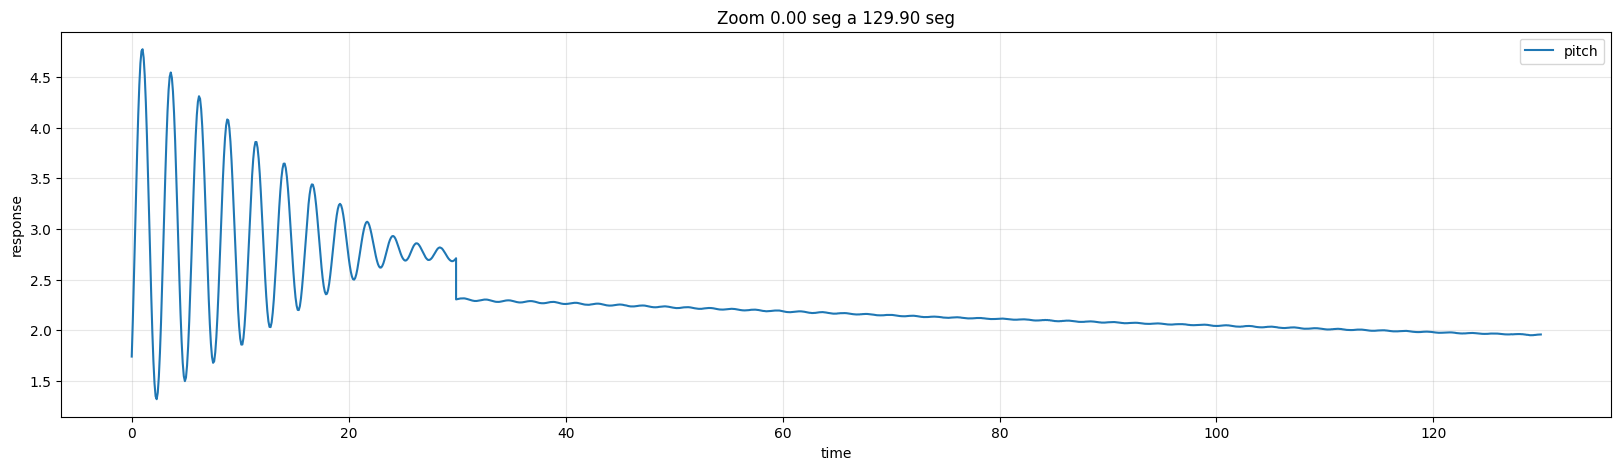

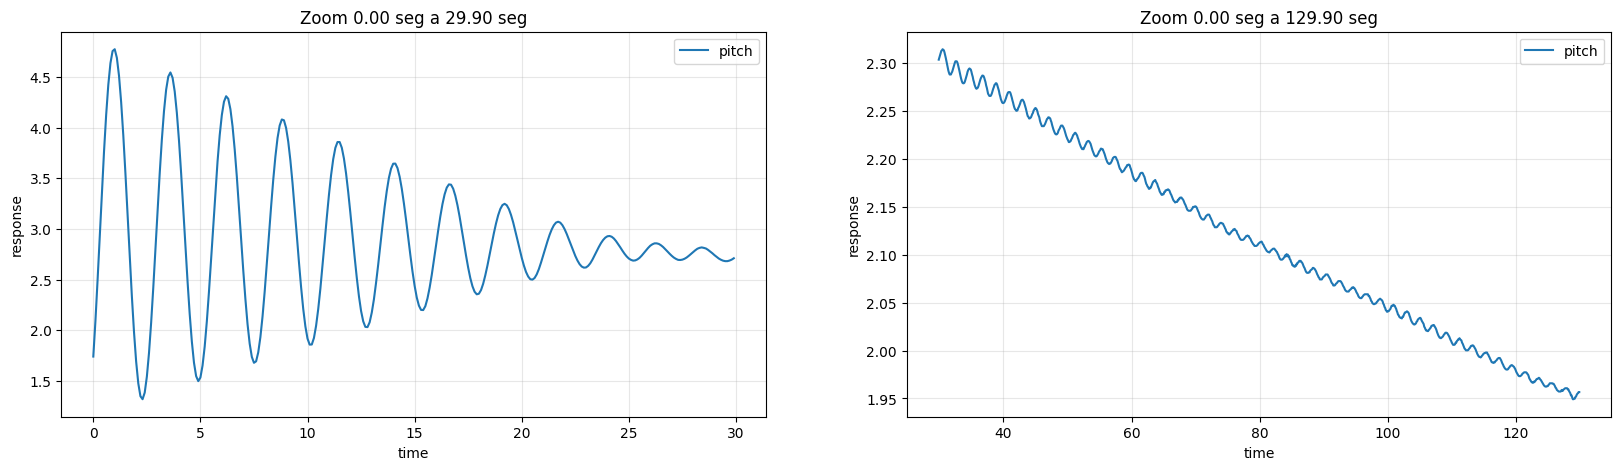

In [44]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [45]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_ay,ref_sample_time,ref_q1,ref_roll,ref_wz,ref_la_pos_mon_d,ref_wy,ref_q3,ref_pitch,ref_q2,ref_wx,ref_az,ref_ax,ref_q0,ref_yaw,static
0,0.0,9.770,605000000.0,-0.20360,-88.92305,3.089388,-1.404,-0.055961,0.6888,1.738354,-0.6702,0.042531,-0.1864,0.1592,0.186700,147.994998,False
1,0.1,9.777,705000000.0,-0.20560,-88.92305,3.720788,-1.404,-0.097346,0.6894,2.093015,-0.6696,0.043699,-0.1864,0.1522,0.184500,147.994998,False
2,0.2,9.785,805000000.0,-0.20790,-88.92305,4.145350,-1.404,-0.161345,0.6901,2.496377,-0.6689,0.009305,-0.1857,0.1448,0.182000,147.994998,False
3,0.3,9.791,905000000.0,-0.21030,-88.92305,4.332707,-1.404,-0.140375,0.6908,2.924950,-0.6681,0.008417,-0.1853,0.1363,0.179300,148.052294,False
4,0.4,9.795,5000000.0,-0.21280,-88.92305,4.283432,-1.404,-0.107773,0.6915,3.355814,-0.6673,-0.011471,-0.1852,0.1268,0.176600,148.052294,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.786,105000000.0,-0.03197,-88.92305,0.020506,2.007,-0.158423,0.7136,1.953786,-0.6998,0.002401,-0.1856,0.1385,0.008241,176.757480,True
1297,129.6,9.782,205000000.0,-0.03188,-88.92305,0.015539,2.005,-0.162777,0.7136,1.954932,-0.6998,-0.013694,-0.1846,0.1384,0.008133,176.757480,True
1298,129.7,9.784,305000000.0,-0.03179,-88.92305,0.009368,2.004,-0.158079,0.7136,1.955505,-0.6998,-0.002935,-0.1850,0.1378,0.008034,176.814776,True
1299,129.8,9.784,405000000.0,-0.03170,-88.92305,0.009706,2.002,-0.172174,0.7136,1.956651,-0.6998,0.004946,-0.1851,0.1378,0.007925,176.814776,True


In [46]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)